<a href="https://colab.research.google.com/github/ankit-rathi/quantvesting_v3/blob/main/notebooks/06_QUANTVESTING_SIP_MULTI_STRATEGY_BACKTEST_RISK_CONSTRAINED_INTEGER_SHARES_EQUAL_CASH_REDEPLOYMENT_APPLE_TO_APPLE_FINAL_LATEST_NIFTY50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantvesting — Unified 07–14 Apple-to-Apple Multi-Strategy Backtest

This notebook is a consolidated comparison engine built from the supplied **06_QUANTVESTING...APPLE_TO_APPLE_FINAL (1)** baseline and the finalized strategy definitions used in standalone notebooks **07 through 14**.

## Strategies included

1. **07 — ATH Drawdown + Recovery**
2. **08 — Risk-Constrained Original Quantvesting**
3. **09 — 200-DMA Drawdown Top-N**
4. **10 — ATH Drawdown Top-N**
5. **11 — ATH + 200-DMA Composite Top-N**
6. **12 — Trend-Confirmed Pullback Top-N**
7. **13 — Regime-Adaptive Quantvesting**
8. **14 — Relative Strength + Pullback Top-N**
9. **Nifty 50 SIP — Price Index Baseline**

The objective is to change the **selection / exit rule**, while holding the portfolio implementation, capital schedule, transaction assumptions, integer-share mechanics, position risk, sector purchase cap, cash policy, accounting and comparison outputs constant.

> **Important:** This is a historical research comparison, not a forecast. Run top-to-bottom in a fresh runtime. The notebook downloads the same market universe from `sample_data/signals.csv` and uses point-in-time signals with next-trading-day execution.

In [1]:
# 1. Dependencies
from pathlib import Path
import math, re, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from IPython.display import display
warnings.filterwarnings("ignore")

In [2]:
# 2. COMMON CONFIGURATION — intentionally aligned with finalized standalone 07–14 notebooks
SIGNAL_FILE = Path("sample_data/signals.csv")
START_DATE = "2016-10-01"
END_DATE = "2026-09-30"
EXPECTED_MONTHS = None
INITIAL_LUMP_SUM = 0
MONTHLY_SIP = 100_000
SIP_IN_FIRST_MONTH = True

TOP_N = 20
MAX_HOLDINGS = 40
MAX_POSITION_PCT = 0.05
POSITION_REVIEW_PCT = 0.12
POSITION_HARD_PCT = 0.15
POSITION_TRIM_TARGET_PCT = 0.12
MAX_SECTOR_PCT = 0.20
TRANSACTION_COST_BPS = 10
SLIPPAGE_BPS = 5
HISTORY_PERIOD = "max"
ALLOW_REPEAT_BUYS = True
TARGET_CASH_BUFFER_PCT = 0.05
AS_OF_DATE = None

# Strategy-specific fixed research specifications
ATH_DRAWDOWN_MIN = 0.20
DMA_WINDOW = 200

FAST_DMA_WINDOW = 50
SLOW_DMA_WINDOW = 200
TREND_SLOPE_LOOKBACK = 50
PULLBACK_LOOKBACK = 252
MIN_PULLBACK = 0.10

RISK_ON_BREADTH_MIN = 0.60
RISK_OFF_BREADTH_MAX = 0.40
RISK_ON_WEIGHTS = (0.20, 0.20, 0.20, 0.40)
NEUTRAL_WEIGHTS = (0.25, 0.25, 0.25, 0.25)
RISK_OFF_WEIGHTS = (0.30, 0.30, 0.25, 0.15)

RS_6M_WINDOW = 126
RS_12M_WINDOW = 252
RS_SKIP_DAYS = 21
RS_WEIGHTS = (0.30, 0.30, 0.40)  # 6M RS, 12M RS, pullback

STRATEGIES = [
    "07 — ATH Drawdown + Recovery",
    "08 — Risk-Constrained Original Quantvesting",
    "09 — 200-DMA Drawdown Top-N",
    "10 — ATH Drawdown Top-N",
    "11 — ATH + 200-DMA Composite Top-N",
    "12 — Trend-Confirmed Pullback Top-N",
    "13 — Regime-Adaptive Quantvesting",
    "14 — Relative Strength + Pullback Top-N",
]

COST_RATE = TRANSACTION_COST_BPS / 10_000
SLIP_RATE = SLIPPAGE_BPS / 10_000

In [3]:
# 3. Configuration validation
if not SIGNAL_FILE.exists():
    raise FileNotFoundError(f"Signal file not found: {SIGNAL_FILE.resolve()}")
if pd.Timestamp(END_DATE) < pd.Timestamp(START_DATE): raise ValueError("END_DATE before START_DATE")
if MIN_PULLBACK <= 0 or MIN_PULLBACK >= 1: raise ValueError("MIN_PULLBACK must be between 0 and 1")
if MAX_HOLDINGS <= 0 or TOP_N <= 0: raise ValueError("TOP_N/MAX_HOLDINGS must be positive")
if MAX_POSITION_PCT <= 0 or MAX_POSITION_PCT > 1: raise ValueError("Invalid position cap")
if POSITION_TRIM_TARGET_PCT > POSITION_HARD_PCT: raise ValueError("Trim target must not exceed hard threshold")
if MAX_SECTOR_PCT <= 0 or MAX_SECTOR_PCT > 1: raise ValueError("Invalid sector cap")
if RS_6M_WINDOW >= RS_12M_WINDOW or RS_SKIP_DAYS >= RS_6M_WINDOW: raise ValueError("Invalid RS windows")
if not (0 < RISK_OFF_BREADTH_MAX < RISK_ON_BREADTH_MIN < 1): raise ValueError("Invalid regime thresholds")
print("Configuration validated")
print(f"Journey: {START_DATE} → {END_DATE}")
print(f"Monthly SIP: ₹{MONTHLY_SIP:,.0f} | Initial lump sum: ₹{INITIAL_LUMP_SUM:,.0f}")
print(f"Common portfolio: {MAX_HOLDINGS} holdings | {MAX_POSITION_PCT:.0%} purchase cap | {MAX_SECTOR_PCT:.0%} sector purchase cap | {TARGET_CASH_BUFFER_PCT:.0%} cash target")

Configuration validated
Journey: 2016-10-01 → 2026-09-30
Monthly SIP: ₹100,000 | Initial lump sum: ₹0
Common portfolio: 40 holdings | 5% purchase cap | 20% sector purchase cap | 5% cash target


In [4]:
# 4. Load and validate the common signal universe
signals_config = pd.read_csv(SIGNAL_FILE)
signals_config.columns = [str(c).strip().lower() for c in signals_config.columns]
required = {"symbol", "conviction", "category"}
missing = required - set(signals_config.columns)
if missing: raise ValueError(f"signals.csv missing columns: {sorted(missing)}")
signals_config["symbol"] = signals_config["symbol"].astype(str).str.strip().str.upper()
signals_config["conviction"] = signals_config["conviction"].astype(str).str.strip().str.upper()
signals_config["category"] = signals_config["category"].astype(str).str.strip().replace({"": "Unknown"})
if signals_config["symbol"].duplicated().any(): raise ValueError("Duplicate symbols in signals.csv")
signals_config = signals_config[signals_config["conviction"].isin(["X-LC","H-LC"])].copy()
signals_config = signals_config[signals_config["symbol"] != "LTIM"].reset_index(drop=True)
signals_config["conviction_rank"] = signals_config["conviction"].map({"X-LC":1,"H-LC":2})
CATEGORY_MAP = dict(zip(signals_config["symbol"], signals_config["category"]))
YF_TICKERS = {f"{s}.NS":s for s in signals_config["symbol"]}
if len(signals_config) < MAX_HOLDINGS: raise ValueError("Universe is smaller than MAX_HOLDINGS")
print(f"Universe: {len(signals_config)} stocks")
display(signals_config.head(20).style.hide(axis="index"))

Universe: 53 stocks


symbol,conviction,category,conviction_rank
TMPV,X-LC,AUTO,1
TCS,X-LC,IT,1
ITC,X-LC,FMCG,1
INFY,X-LC,IT,1
JIOFIN,X-LC,FINANCE,1
VBL,X-LC,FMCG,1
BAJAJFINSV,X-LC,FINANCE,1
LTM,H-LC,IT,2
DLF,H-LC,REALTY,2
HDFCLIFE,X-LC,INSURANCE,1


In [5]:
# 5. Download the common daily market dataset once for every strategy
market_download_end = (pd.Timestamp(END_DATE) + pd.Timedelta(days=2)).strftime("%Y-%m-%d")
def yf_download(tickers, start=None, end=None, period=None):
    kwargs = dict(tickers=tickers, interval="1d", auto_adjust=False, actions=False, progress=False, repair=True, group_by="column")
    if period is not None: kwargs["period"] = period
    else: kwargs.update(start=start, end=end)
    return yf.download(**kwargs)
raw = yf_download(list(YF_TICKERS.keys()), period=HISTORY_PERIOD)
rows=[]
if isinstance(raw.columns, pd.MultiIndex):
    fields=set(raw.columns.get_level_values(0))
    for field in ["Open","High","Low","Close"]:
        if field not in fields: continue
        block=raw[field]
        if isinstance(block,pd.Series): block=block.to_frame()
        for ticker in block.columns:
            sym=YF_TICKERS.get(str(ticker),str(ticker).replace(".NS",""))
            s=pd.to_numeric(block[ticker],errors="coerce")
            for d,v in s.dropna().items(): rows.append((pd.Timestamp(d).tz_localize(None),sym,field,float(v)))
else:
    ticker=list(YF_TICKERS.keys())[0]; sym=YF_TICKERS[ticker]
    for field in ["Open","High","Low","Close"]:
        if field in raw.columns:
            s=pd.to_numeric(raw[field],errors="coerce")
            for d,v in s.dropna().items(): rows.append((pd.Timestamp(d).tz_localize(None),sym,field,float(v)))
long=pd.DataFrame(rows,columns=["date","symbol","field","value"])
if long.empty: raise RuntimeError("No market data downloaded")
prices=long.pivot_table(index=["date","symbol"],columns="field",values="value",aggfunc="last").reset_index()
prices=prices.sort_values(["symbol","date"]).reset_index(drop=True)
prices=prices[prices["date"]<=pd.Timestamp(END_DATE)].copy()
print(f"Downloaded {len(prices):,} daily rows across {prices['symbol'].nunique()} stocks")
print(f"Data: {prices['date'].min():%d %b %Y} → {prices['date'].max():%d %b %Y}")

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['PIDILITIND.NS']: IntCastingNaNError('Cannot convert non-finite values (NA or inf) to integer')


Downloaded 293,235 daily rows across 52 stocks
Data: 02 Jan 1991 → 22 Sep 2026


In [6]:
# 6. Point-in-time common and strategy-specific indicators
p=prices.copy()
p["conviction"]=p["symbol"].map(dict(zip(signals_config.symbol,signals_config.conviction)))
p["conviction_rank"]=p["symbol"].map(dict(zip(signals_config.symbol,signals_config.conviction_rank)))
p["category"]=p["symbol"].map(CATEGORY_MAP)
p["running_ath"]=p.groupby("symbol")["Close"].cummax()
p["ath_gap"]=(p["running_ath"]-p["Close"])/p["Close"]
p["ath_drawdown"]=p["Close"]/p["running_ath"]-1
p["dma_200"]=p.groupby("symbol")["Close"].transform(lambda s:s.rolling(200,min_periods=200).mean())
p["dma_gap"]=(p["dma_200"]-p["Close"])/p["Close"]
p["above_dma200"]=p["Close"]>=p["dma_200"]
p["dma_50"]=p.groupby("symbol")["Close"].transform(lambda s:s.rolling(50,min_periods=50).mean())
p["dma_200_slope_base"]=p.groupby("symbol")["dma_200"].shift(TREND_SLOPE_LOOKBACK)
p["trend_distance"]=p["Close"]/p["dma_200"]-1
p["trend_alignment"]=p["dma_50"]/p["dma_200"]-1
p["trend_slope"]=p["dma_200"]/p["dma_200_slope_base"]-1
p["trailing_high"]=p.groupby("symbol")["Close"].transform(lambda s:s.rolling(PULLBACK_LOOKBACK,min_periods=PULLBACK_LOOKBACK).max())
p["pullback"]=1-p["Close"]/p["trailing_high"]
p["trend_confirmed"]=(p["Close"]>p["dma_200"])&(p["dma_50"]>p["dma_200"])&(p["trend_slope"]>0)
p["rs_6m"]=p.groupby("symbol")["Close"].transform(lambda s:s.shift(RS_SKIP_DAYS)/s.shift(RS_6M_WINDOW+RS_SKIP_DAYS)-1)
p["rs_12m"]=p.groupby("symbol")["Close"].transform(lambda s:s.shift(RS_SKIP_DAYS)/s.shift(RS_12M_WINDOW+RS_SKIP_DAYS)-1)
# Point-in-time regime from the same universe
p["breadth_200dma"]=p.groupby("date")["trend_distance"].transform(lambda x: float((x.dropna()>0).mean()) if len(x.dropna()) else np.nan)
p["median_trend_slope"]=p.groupby("date")["trend_slope"].transform("median")
p["market_regime"]=np.select([(p["breadth_200dma"]>=RISK_ON_BREADTH_MIN)&(p["median_trend_slope"]>0),(p["breadth_200dma"]<=RISK_OFF_BREADTH_MAX)|(p["median_trend_slope"]<0)], ["Risk-On","Risk-Off"], default="Neutral")
prices=p

In [7]:
# 7. Common monthly contribution calendar
window=prices[(prices.date>=pd.Timestamp(START_DATE))&(prices.date<=pd.Timestamp(END_DATE))]
market_days=pd.DatetimeIndex(sorted(window.date.unique()))
month_first=pd.Series(market_days,index=market_days).groupby(market_days.to_period("M")).first()
sip_dates_all=pd.DatetimeIndex(month_first.values)
first_month=sip_dates_all[0].to_period("M")
sip_dates=pd.DatetimeIndex([d for d in sip_dates_all if SIP_IN_FIRST_MONTH or d.to_period("M")!=first_month])
INITIAL_CONTRIBUTION_DATE=pd.Timestamp(sip_dates_all[0])
SIP_SET=set(sip_dates)
print(f"Journey months: {len(sip_dates_all)}")
print(f"External contributions: ₹{INITIAL_LUMP_SUM + MONTHLY_SIP*len(sip_dates):,.0f}")

Journey months: 120
External contributions: ₹12,000,000


## 8. Strategy signal definitions

The following definitions are taken from the finalized standalone 07–14 research specifications. **Only the signal/exit logic differs; the portfolio engine below is common.**

- **07:** `ath_gap >= 20%` and `Close >= 200DMA`; rank by largest ATH gap.
- **08:** monthly `ath_gap > 20%`, ranked by ATH gap, with the original Quantvesting frozen-entry-ATH daily exit rule.
- **09:** `dma_gap > 0`, ranked by largest distance below 200DMA.
- **10:** `ath_gap >= 20%`, ranked by largest ATH gap.
- **11:** cross-sectional percentile ranks of ATH distance and 200DMA distance, 50/50 composite.
- **12:** trend confirmed (`Close > 200DMA`, `50DMA > 200DMA`, rising 200DMA) plus ≥10% pullback; 20/20/20/40 composite of trend-distance, alignment, slope and pullback ranks.
- **13:** same trend-confirmed + pullback candidate set as 12, but score weights change by point-in-time Risk-On / Neutral / Risk-Off regime.
- **14:** `Close > 200DMA`, ≥10% pullback, and 6M/12M relative-strength signals using a 21-trading-day skip; 30/30/40 composite of 6M RS, 12M RS and pullback ranks.

In [8]:
# 9. Candidate selector — point-in-time only

def pct_rank(s): return s.rank(method="average",pct=True)

def regime_weights(regime):
    return {"Risk-On":RISK_ON_WEIGHTS,"Risk-Off":RISK_OFF_WEIGHTS}.get(regime,NEUTRAL_WEIGHTS)

def candidates_on_date(signal_date, strategy):
    d=prices[prices.date==pd.Timestamp(signal_date)].copy()
    if d.empty: return d
    d=d[d.symbol.isin(signals_config.symbol)].copy()
    d["conviction_priority"]=d["conviction_rank"].fillna(99)
    if strategy.startswith("07"):
        q=d[(d.ath_gap>=ATH_DRAWDOWN_MIN)&(d.Close>=d.dma_200)].copy()
        return q.sort_values(["ath_gap","conviction_priority","symbol"],ascending=[False,True,True]).head(TOP_N).reset_index(drop=True)
    if strategy.startswith("09"):
        q=d[d.dma_gap>0].copy()
        return q.sort_values(["dma_gap","conviction_priority","symbol"],ascending=[False,True,True]).head(TOP_N).reset_index(drop=True)
    if strategy.startswith("10"):
        q=d[d.ath_gap>=ATH_DRAWDOWN_MIN].copy()
        return q.sort_values(["ath_gap","conviction_priority","symbol"],ascending=[False,True,True]).head(TOP_N).reset_index(drop=True)
    if strategy.startswith("11"):
        q=d[d.ath_gap.notna()&d.dma_gap.notna()].copy()
        q["ath_rank"]=pct_rank(q.ath_gap); q["dma_rank"]=pct_rank(q.dma_gap)
        q["composite_score"]=0.5*q.ath_rank+0.5*q.dma_rank
        return q.sort_values(["composite_score","conviction_priority","symbol"],ascending=[False,True,True]).head(TOP_N).reset_index(drop=True)
    if strategy.startswith("12"):
        q=d[d.trend_confirmed & (d.pullback>=MIN_PULLBACK) & d[["trend_distance","trend_alignment","trend_slope","pullback"]].notna().all(axis=1)].copy()
        if q.empty:return q
        q["trend_distance_rank"]=pct_rank(q.trend_distance); q["trend_alignment_rank"]=pct_rank(q.trend_alignment); q["trend_slope_rank"]=pct_rank(q.trend_slope); q["pullback_rank"]=pct_rank(q.pullback)
        q["composite_score"]=0.20*q.trend_distance_rank+0.20*q.trend_alignment_rank+0.20*q.trend_slope_rank+0.40*q.pullback_rank
        return q.sort_values(["composite_score","conviction_priority","symbol"],ascending=[False,True,True]).head(TOP_N).reset_index(drop=True)
    if strategy.startswith("13"):
        q=d[d.trend_confirmed & (d.pullback>=MIN_PULLBACK) & d[["trend_distance","trend_alignment","trend_slope","pullback"]].notna().all(axis=1)].copy()
        if q.empty:return q
        regime=str(q.market_regime.dropna().iloc[0]) if q.market_regime.notna().any() else "Neutral"
        wd,wa,ws,wp=regime_weights(regime)
        q["trend_distance_rank"]=pct_rank(q.trend_distance); q["trend_alignment_rank"]=pct_rank(q.trend_alignment); q["trend_slope_rank"]=pct_rank(q.trend_slope); q["pullback_rank"]=pct_rank(q.pullback)
        q["composite_score"]=(wd*q.trend_distance_rank+wa*q.trend_alignment_rank+ws*q.trend_slope_rank+wp*q.pullback_rank)/(wd+wa+ws+wp)
        q["regime_weight_profile"]=regime
        return q.sort_values(["composite_score","conviction_priority","symbol"],ascending=[False,True,True]).head(TOP_N).reset_index(drop=True)
    if strategy.startswith("14"):
        q=d[(d.Close>d.dma_200)&(d.pullback>=MIN_PULLBACK)&d[["rs_6m","rs_12m","pullback"]].notna().all(axis=1)].copy()
        if q.empty:return q
        q["rs_6m_rank"]=pct_rank(q.rs_6m); q["rs_12m_rank"]=pct_rank(q.rs_12m); q["pullback_rank"]=pct_rank(q.pullback)
        q["composite_score"]=0.30*q.rs_6m_rank+0.30*q.rs_12m_rank+0.40*q.pullback_rank
        return q.sort_values(["composite_score","conviction_priority","symbol"],ascending=[False,True,True]).head(TOP_N).reset_index(drop=True)
    if strategy.startswith("08"):
        q=d[d.ath_gap>ATH_DRAWDOWN_MIN].copy()
        return q.sort_values(["ath_gap","conviction_priority","symbol"],ascending=[False,True,True]).head(TOP_N).reset_index(drop=True)
    raise ValueError(strategy)

In [9]:
# 10. Common portfolio accounting and execution helpers

def market_value(positions, last_close):
    return sum(int(v["shares"])*float(last_close[s]) for s,v in positions.items() if s in last_close and np.isfinite(last_close[s]))

def trim_overweight_positions(day, positions, cash, last_close, strategy, date):
    if not positions:return positions,cash,[]
    vals={}
    for s,pos in positions.items():
        if s in day.index:
            px=float(day.loc[s,"Open"])
            if np.isfinite(px) and px>0: vals[s]=int(pos["shares"])*px
    corpus=cash+sum(vals.values())
    if corpus<=0:return positions,cash,[]
    events=[]
    for s in list(positions):
        if s not in vals:continue
        cur=vals[s]/corpus
        if cur<=POSITION_HARD_PCT:continue
        px=float(day.loc[s,"Open"]); sell_px=px*(1-SLIP_RATE)
        target=corpus*POSITION_TRIM_TARGET_PCT
        qty=min(int(positions[s]["shares"]),int(math.floor(max(0,vals[s]-target)/sell_px+1e-12)))
        if qty<=0:continue
        gross=qty*sell_px; cost=gross*COST_RATE; cash_before=cash; cash+=gross-cost
        positions[s]["shares"]-=qty
        events.append({"date":date,"event":"TRIM","strategy":strategy,"symbol":s,"sector":positions[s].get("category",CATEGORY_MAP.get(s,"Unknown")),"shares":-qty,"price":sell_px,"notional":gross,"cost":cost,"cash_before":cash_before,"cash_after":cash,"reason":f"Position {cur:.2%} > hard {POSITION_HARD_PCT:.0%}; trim toward {POSITION_TRIM_TARGET_PCT:.0%}","position_pct_before":cur})
        if positions[s]["shares"]==0:del positions[s]
    return positions,cash,events

def buy_one(symbol, day, positions, cash, corpus, last_close, strategy, row, max_trade_cash):
    if symbol not in day.index or cash<=0 or corpus<=0:return positions,cash,None
    held=symbol in positions
    if not held and len(positions)>=MAX_HOLDINGS:return positions,cash,None
    if held and not ALLOW_REPEAT_BUYS:return positions,cash,None
    open_px=float(day.loc[symbol,"Open"])
    if not np.isfinite(open_px) or open_px<=0:return positions,cash,None
    entry_px=open_px*(1+SLIP_RATE); all_in=entry_px*(1+COST_RATE)
    current_value=int(positions.get(symbol,{}).get("shares",0))*entry_px
    sector=CATEGORY_MAP.get(symbol,"Unknown")
    sector_value=0.0
    for s,pos in positions.items():
        if pos.get("category",CATEGORY_MAP.get(s,"Unknown"))==sector:
            px=float(day.loc[s,"Open"])*(1+SLIP_RATE) if s in day.index else float(last_close.get(s,0))
            if np.isfinite(px) and px>0:sector_value+=int(pos["shares"])*px
    pos_room=max(0,corpus*MAX_POSITION_PCT-current_value)
    sec_room=max(0,corpus*MAX_SECTOR_PCT-sector_value)
    target=min(cash,max_trade_cash,pos_room,sec_room)
    qty=int(math.floor(target/all_in))
    if qty<=0:return positions,cash,None
    notional=qty*entry_px; cost=notional*COST_RATE; total=notional+cost
    if total>cash+1e-9:
        qty=int(math.floor(cash/all_in)); notional=qty*entry_px; cost=notional*COST_RATE; total=notional+cost
    if qty<=0 or total>cash+1e-9:return positions,cash,None
    before=cash;cash-=total
    if held:positions[symbol]["shares"]+=qty
    else:positions[symbol]={"shares":qty,"category":sector,"entry_ath":row.get("running_ath",np.nan),"signal_date":row.get("signal_date",pd.NaT),"conviction":row.get("conviction",np.nan),"rank":row.get("rank",np.nan)}
    return positions,cash,{"date":None,"event":"SIP BUY","strategy":strategy,"symbol":symbol,"sector":sector,"shares":qty,"price":entry_px,"notional":notional,"cost":cost,"cash_before":before,"cash_after":cash,"position_pct_after":(current_value+notional)/corpus if corpus else np.nan,"sector_pct_after":(sector_value+notional)/corpus if corpus else np.nan}

def deploy_equal_cash(day, candidates, positions, cash, corpus, last_close, strategy, signal_date, execution_date=None):
    if candidates.empty or cash<=0:return positions,cash,[]
    c=candidates.copy(); c["conviction_priority"]=c["conviction_rank"].fillna(99)
    c=c.sort_values(["conviction_priority","symbol"],ascending=[True,True]).reset_index(drop=True)
    meta={r.symbol:r for _,r in c.iterrows()}; active=list(c.symbol); events=[]
    while active and cash>0 and corpus>0:
        reserve=corpus*TARGET_CASH_BUFFER_PCT; deployable=max(0,cash-reserve)
        if deployable<=1e-8:break
        target_each=deployable/len(active);progress=False; next_active=[]
        for s in active:
            if cash<=reserve+1e-8:break
            row=meta[s]
            positions,cash,e=buy_one(s,day,positions,cash,corpus,last_close,strategy,{**row.to_dict(),"signal_date":signal_date},target_each)
            if e:
                progress=True;e.update({"date":execution_date,"signal_date":signal_date,"conviction":row.get("conviction"),"conviction_rank":row.get("conviction_rank"),"ath_gap":row.get("ath_gap"),"dma_gap":row.get("dma_gap"),"rs_6m":row.get("rs_6m"),"rs_12m":row.get("rs_12m"),"pullback":row.get("pullback"),"composite_score":row.get("composite_score"),"market_regime":row.get("market_regime")});events.append(e)
            next_active.append(s)
        if not progress:break
        active=next_active
    return positions,cash,events

In [10]:
# 11. Common monthly no-sell engine for 07, 09, 10, 11, 12, 13, 14

def run_monthly_strategy(strategy):
    df=prices.sort_values(["date","symbol"])
    dates=pd.DatetimeIndex(sorted(df[df.date>=pd.Timestamp(START_DATE)].date.unique()))
    positions={};cash=0.0;contributed=0.0;rows=[];trades=[];contribs=[];last_close={}
    for date in dates:
        date=pd.Timestamp(date); day=df[df.date==date].set_index("symbol")
        if date==INITIAL_CONTRIBUTION_DATE: cash+=INITIAL_LUMP_SUM;contributed+=INITIAL_LUMP_SUM;contribs.append({"date":date,"contribution":INITIAL_LUMP_SUM,"type":"INITIAL LUMP SUM"})
        if date in SIP_SET:
            cash+=MONTHLY_SIP;contributed+=MONTHLY_SIP;contribs.append({"date":date,"contribution":MONTHLY_SIP,"type":"MONTHLY SIP"})
            positions,cash,tr=trim_overweight_positions(day,positions,cash,last_close,strategy,date);trades.extend(tr)
            pre_invested=market_value(positions,{s:float(day.loc[s,"Open"]) for s in positions if s in day.index}); corpus=cash+pre_invested
            prev=dates[dates<date]; signal_date=pd.Timestamp(prev[-1]) if len(prev) else pd.NaT
            opp=candidates_on_date(signal_date,strategy) if pd.notna(signal_date) else pd.DataFrame()
            positions,cash,tr=deploy_equal_cash(day,opp,positions,cash,corpus,last_close,strategy,signal_date,execution_date=date);trades.extend(tr)
        for s,r in day.iterrows():
            px=float(r.Close)
            if np.isfinite(px) and px>0:last_close[s]=px
        invested=market_value(positions,last_close); corpus=cash+invested
        rows.append({"date":date,"cash":cash,"invested_value":invested,"portfolio_value":corpus,"contributed_capital":contributed,"open_positions":len(positions),"cash_pct":cash/corpus if corpus else np.nan,"invested_pct":invested/corpus if corpus else np.nan})
    return pd.DataFrame(rows),pd.DataFrame(trades),pd.DataFrame(contribs)

In [11]:
# 12. Original Quantvesting engine (08) — monthly ATH-gap entries + frozen-entry-ATH daily exits
# The common risk controls remain identical. Exit signals are generated only from an EOD close
# reaching the frozen ATH captured at entry, then executed at the next trading-day open.

def run_original_quantvesting():
    df=prices.sort_values(["date","symbol"]); dates=pd.DatetimeIndex(sorted(df[df.date>=pd.Timestamp(START_DATE)].date.unique()))
    positions={};pending={};cash=0.0;contributed=0.0;rows=[];trades=[];contribs=[];last_close={}
    for i,date in enumerate(dates):
        date=pd.Timestamp(date); day=df[df.date==date].set_index("symbol")
        if date==INITIAL_CONTRIBUTION_DATE: cash+=INITIAL_LUMP_SUM;contributed+=INITIAL_LUMP_SUM;contribs.append({"date":date,"contribution":INITIAL_LUMP_SUM,"type":"INITIAL LUMP SUM"})
        if date in SIP_SET:
            cash+=MONTHLY_SIP;contributed+=MONTHLY_SIP;contribs.append({"date":date,"contribution":MONTHLY_SIP,"type":"MONTHLY SIP"})
            positions,cash,tr=trim_overweight_positions(day,positions,cash,last_close,"08 — Risk-Constrained Original Quantvesting",date);trades.extend(tr)
        # Execute previously generated exits at today's open.
        for ex in pending.pop(date,[]):
            s=ex["symbol"]
            if s not in positions or s not in day.index:continue
            qty=int(positions[s]["shares"]); open_px=float(day.loc[s,"Open"])
            if qty<=0 or not np.isfinite(open_px) or open_px<=0:continue
            sell_px=open_px*(1-SLIP_RATE);gross=qty*sell_px;cost=gross*COST_RATE;before=cash;cash+=gross-cost
            trades.append({"date":date,"signal_date":ex["signal_date"],"event":"EXIT","strategy":"08 — Risk-Constrained Original Quantvesting","symbol":s,"sector":positions[s].get("category",CATEGORY_MAP.get(s,"Unknown")),"shares":-qty,"price":sell_px,"notional":gross,"cost":cost,"cash_before":before,"cash_after":cash,"reason":"Frozen entry ATH reached at prior EOD"})
            del positions[s]
        if date in SIP_SET:
            prev=dates[dates<date];signal_date=pd.Timestamp(prev[-1]) if len(prev) else pd.NaT
            opp=candidates_on_date(signal_date,"08 — Risk-Constrained Original Quantvesting") if pd.notna(signal_date) else pd.DataFrame()
            pre=market_value(positions,{s:float(day.loc[s,"Open"]) for s in positions if s in day.index}); corpus=cash+pre
            positions,cash,tr=deploy_equal_cash(day,opp,positions,cash,corpus,last_close,"08 — Risk-Constrained Original Quantvesting",signal_date,execution_date=date);trades.extend(tr)
        # Generate next-day exit signals only after today's EOD close.
        next_date=dates[i+1] if i+1<len(dates) else pd.NaT
        if pd.notna(next_date):
            for s,pos in list(positions.items()):
                if s not in day.index:continue
                close=float(day.loc[s,"Close"]); frozen=pos.get("entry_ath",np.nan)
                if np.isfinite(close) and np.isfinite(frozen) and close>=frozen:
                    pending.setdefault(pd.Timestamp(next_date),[]).append({"symbol":s,"signal_date":date})
        for s,r in day.iterrows():
            px=float(r.Close)
            if np.isfinite(px) and px>0:last_close[s]=px
        invested=market_value(positions,last_close);corpus=cash+invested
        rows.append({"date":date,"cash":cash,"invested_value":invested,"portfolio_value":corpus,"contributed_capital":contributed,"open_positions":len(positions),"cash_pct":cash/corpus if corpus else np.nan,"invested_pct":invested/corpus if corpus else np.nan})
    return pd.DataFrame(rows),pd.DataFrame(trades),pd.DataFrame(contribs)

In [13]:
NIFTY_BENCHMARK_NAME = "Nifty 50 SIP"
NIFTY_TICKER = "^NSEI"

# 13. Nifty 50 SIP benchmark — same contribution calendar, same journey dates, pure index baseline
# This is a theoretical SIP into the Nifty 50 Price Index (^NSEI), not an ETF simulation.
# It uses the same monthly contribution dates and ₹100,000 contribution as every Quantvesting strategy.
# Fractional index units are used because an index itself is not a tradable share. No 5% stock cap,
# sector cap, or 40-stock limit applies to the benchmark. The benchmark is intended as the passive baseline.

nifty_raw = yf_download([NIFTY_TICKER], period=HISTORY_PERIOD)
def _benchmark_extract(raw, field):
    if raw is None or raw.empty:
        return pd.Series(dtype=float)
    if isinstance(raw.columns, pd.MultiIndex):
        if field not in raw.columns.get_level_values(0):
            return pd.Series(dtype=float)
        x=raw[field]
        x=x.iloc[:,0] if isinstance(x,pd.DataFrame) else x
    else:
        x=raw[field]
    x=pd.to_numeric(x,errors="coerce").dropna()
    x.index=pd.to_datetime(x.index).tz_localize(None)
    return x

nifty_open = _benchmark_extract(nifty_raw, "Open")
nifty_close = _benchmark_extract(nifty_raw, "Close")
nifty = pd.DataFrame({"open": nifty_open, "close": nifty_close}).dropna(subset=["open", "close"])
nifty.index = pd.to_datetime(nifty.index).tz_localize(None)
nifty = nifty.loc[(nifty.index >= pd.Timestamp(START_DATE)) & (nifty.index <= pd.Timestamp(END_DATE))].copy()

if nifty.empty:
    raise ValueError("No Nifty 50 (^NSEI) data available for the requested journey.")

# Map each common SIP date to the first available Nifty trading day on/after that date.
def next_nifty_day(d):
    ix = nifty.index[nifty.index >= pd.Timestamp(d)]
    return pd.Timestamp(ix[0]) if len(ix) else pd.NaT

nifty_positions = 0.0
nifty_cash = 0.0
nifty_contributed = 0.0
nifty_rows = []
nifty_trades = []
nifty_contribs = []
for date in nifty.index:
    date = pd.Timestamp(date)
    if date == INITIAL_CONTRIBUTION_DATE:
        nifty_cash += INITIAL_LUMP_SUM
        nifty_contributed += INITIAL_LUMP_SUM
        nifty_contribs.append({"date":date,"contribution":INITIAL_LUMP_SUM,"type":"INITIAL LUMP SUM"})
    if date in set(nifty.index.intersection(sip_dates)):
        nifty_cash += MONTHLY_SIP
        nifty_contributed += MONTHLY_SIP
        nifty_contribs.append({"date":date,"contribution":MONTHLY_SIP,"type":"MONTHLY SIP"})
        px=float(nifty.loc[date,"open"])
        if np.isfinite(px) and px>0 and nifty_cash>0:
            # The index benchmark is fully deployed at the execution price.
            units=nifty_cash/px
            nifty_positions += units
            gross=units*px
            nifty_trades.append({"date":date,"signal_date":date,"event":"BUY","strategy":NIFTY_BENCHMARK_NAME,"symbol":"NIFTY50","sector":"INDEX","shares":units,"price":px,"notional":gross,"cost":0.0,"cash_before":nifty_cash,"cash_after":0.0,"position_pct_after":1.0,"sector_pct_after":1.0,"reason":"Monthly SIP benchmark purchase"})
            nifty_cash=0.0
    value=nifty_cash+nifty_positions*float(nifty.loc[date,"close"])
    nifty_rows.append({"date":date,"cash":nifty_cash,"invested_value":nifty_positions*float(nifty.loc[date,"close"]),"portfolio_value":value,"contributed_capital":nifty_contributed,"open_positions":1 if nifty_positions>0 else 0,"cash_pct":nifty_cash/value if value else np.nan,"invested_pct":(nifty_positions*float(nifty.loc[date,"close"]))/value if value else np.nan})

nifty_portfolio=pd.DataFrame(nifty_rows)
nifty_trades=pd.DataFrame(nifty_trades)
nifty_contributions=pd.DataFrame(nifty_contribs)
print(f"✓ {NIFTY_BENCHMARK_NAME}: {len(nifty_trades):,} SIP purchase events")


✓ Nifty 50 SIP: 117 SIP purchase events


In [14]:
# 14. Run all eight Quantvesting strategies + Nifty 50 SIP baseline
results={}
for strategy in STRATEGIES:
    if strategy.startswith("08"):
        p,t,c=run_original_quantvesting()
    else:
        p,t,c=run_monthly_strategy(strategy)
    results[strategy]={"portfolio":p,"trades":t,"contributions":c}
    print(f"✓ {strategy}: {len(t):,} trade events")

results[NIFTY_BENCHMARK_NAME]={"portfolio":nifty_portfolio,"trades":nifty_trades,"contributions":nifty_contributions}
print(f"✓ {NIFTY_BENCHMARK_NAME}: {len(nifty_trades):,} SIP purchase events")


✓ 07 — ATH Drawdown + Recovery: 2,142 trade events
✓ 08 — Risk-Constrained Original Quantvesting: 6,671 trade events
✓ 09 — 200-DMA Drawdown Top-N: 4,258 trade events
✓ 10 — ATH Drawdown Top-N: 5,452 trade events
✓ 11 — ATH + 200-DMA Composite Top-N: 6,377 trade events
✓ 12 — Trend-Confirmed Pullback Top-N: 1,410 trade events
✓ 13 — Regime-Adaptive Quantvesting: 1,410 trade events
✓ 14 — Relative Strength + Pullback Top-N: 2,529 trade events
✓ Nifty 50 SIP: 117 SIP purchase events


In [15]:
# 14. Performance metrics

def add_drawdown(p):
    p=p.copy();p["peak"]=p.portfolio_value.cummax();p["drawdown"]=p.portfolio_value/p.peak-1;return p

def xirr(cashflows):
    if len(cashflows)<2:return np.nan
    cf=cashflows.copy();cf["date"]=pd.to_datetime(cf.date);dates=cf.date.dt.to_pydatetime();amounts=cf.amount.astype(float).to_numpy();t0=dates[0];years=np.array([(d-t0).days/365.25 for d in dates])
    def npv(r): return np.sum(amounts/((1+r)**years))
    lo,hi=-0.9999,10.0;flo,fhi=npv(lo),npv(hi)
    if not np.isfinite(flo) or not np.isfinite(fhi) or flo*fhi>0:return np.nan
    for _ in range(250):
        mid=(lo+hi)/2;fm=npv(mid)
        if abs(fm)<1e-9:return mid
        if flo*fm<=0:hi=mid
        else:lo=mid;flo=fm
    return (lo+hi)/2

metric_rows=[]
for name,v in results.items():
    p=add_drawdown(v["portfolio"]);v["portfolio"]=p;t=v["trades"];contributed=float(p.contributed_capital.iloc[-1]);end=float(p.portfolio_value.iloc[-1]);
    cf=[{"date":d,"amount":-a} for d,a in v["contributions"].loc[:,["date","contribution"]].itertuples(index=False,name=None)] if not v["contributions"].empty else []
    cf.append({"date":p.date.iloc[-1],"amount":end});irr=xirr(pd.DataFrame(cf))
    metric_rows.append({"Strategy":name,"Ending Corpus":end,"Profit":end-contributed,"XIRR":irr,"Max Drawdown":float(p.drawdown.min()),"Average Invested %":float(p.invested_pct.mean()),"Average Cash %":float(p.cash_pct.mean()),"Final Cash":float(p.cash.iloc[-1]),"Deployment %":float(p.invested_pct.mean()),"Final Holdings":int(p.open_positions.iloc[-1]),"Buy Events":int(t.event.astype(str).str.contains("BUY|ENTRY",regex=True).sum()) if not t.empty else 0,"Trim Events":int((t.event=="TRIM").sum()) if not t.empty else 0,"Exit Events":int((t.event=="EXIT").sum()) if not t.empty else 0,"Contributed Capital":contributed})
metrics=pd.DataFrame(metric_rows).set_index("Strategy")

In [16]:
# 16. Main apples-to-apples comparison dashboard — sorted descending by XIRR
headline=metrics[["Ending Corpus","Profit","XIRR","Max Drawdown","Average Invested %","Average Cash %","Final Cash","Final Holdings","Buy Events","Trim Events","Exit Events","Contributed Capital"]].copy()
headline["Profit % of Contributions"]=headline.Profit/headline["Contributed Capital"]
headline=headline.sort_values("XIRR",ascending=False)
headline.insert(0,"XIRR Rank",range(1,len(headline)+1))
print("Final comparison — sorted descending by XIRR")
display(headline.style.format({"XIRR Rank":"{:,.0f}","Ending Corpus":"₹{:,.0f}","Profit":"₹{:,.0f}","XIRR":"{:.2%}","Max Drawdown":"{:.2%}","Average Invested %":"{:.1%}","Average Cash %":"{:.1%}","Final Cash":"₹{:,.0f}","Final Holdings":"{:,.0f}","Buy Events":"{:,.0f}","Trim Events":"{:,.0f}","Exit Events":"{:,.0f}","Contributed Capital":"₹{:,.0f}","Profit % of Contributions":"{:.1%}"}))


Final comparison — sorted descending by XIRR


,XIRR Rank,Ending Corpus,Profit,XIRR,Max Drawdown,Average Invested %,Average Cash %,Final Cash,Final Holdings,Buy Events,Trim Events,Exit Events,Contributed Capital,Profit % of Contributions
Strategy,,,,,,,,,,,,,,
10 — ATH Drawdown Top-N,1,"₹30,854,246","₹18,854,246",18.05%,-33.56%,94.2%,5.8%,"₹1,603,684",40,"5,452",0,0,"₹12,000,000",157.1%
11 — ATH + 200-DMA Composite Top-N,2,"₹30,008,499","₹18,008,499",17.53%,-32.93%,94.2%,5.8%,"₹1,559,659",40,"6,377",0,0,"₹12,000,000",150.1%
07 — ATH Drawdown + Recovery,3,"₹29,890,556","₹17,890,556",17.46%,-33.79%,92.5%,7.5%,"₹1,552,658",40,"2,142",0,0,"₹12,000,000",149.1%
14 — Relative Strength + Pullback Top-N,4,"₹29,689,958","₹17,689,958",17.33%,-35.64%,92.9%,7.1%,"₹1,540,258",40,"2,529",0,0,"₹12,000,000",147.4%
09 — 200-DMA Drawdown Top-N,5,"₹29,506,309","₹17,506,309",17.22%,-30.98%,93.6%,6.4%,"₹1,530,181",40,"4,258",0,0,"₹12,000,000",145.9%
13 — Regime-Adaptive Quantvesting,6,"₹28,288,980","₹16,288,980",16.43%,-35.42%,90.3%,9.7%,"₹1,463,115",40,"1,410",0,0,"₹12,000,000",135.7%
12 — Trend-Confirmed Pullback Top-N,7,"₹28,288,980","₹16,288,980",16.43%,-35.42%,90.3%,9.7%,"₹1,463,115",40,"1,410",0,0,"₹12,000,000",135.7%
08 — Risk-Constrained Original Quantvesting,8,"₹28,122,445","₹16,122,445",16.32%,-35.58%,88.2%,11.8%,"₹1,468,318",27,"6,554",0,117,"₹12,000,000",134.4%
Nifty 50 SIP,9,"₹18,993,300","₹7,293,300",9.45%,-36.17%,100.0%,0.0%,₹0,1,117,0,0,"₹11,700,000",62.3%


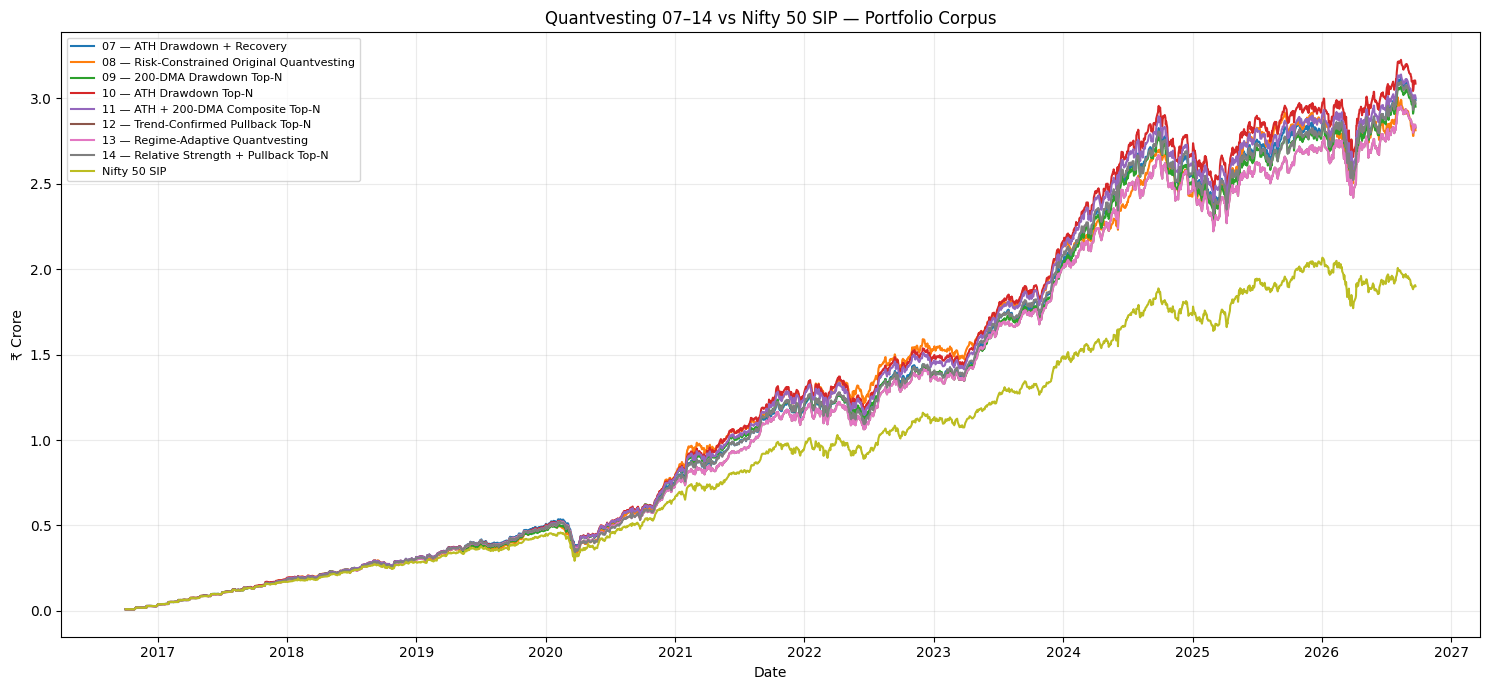

In [17]:
# 17. Corpus comparison chart — strategies vs Nifty 50 SIP baseline
plt.figure(figsize=(15,7))
for name,v in results.items(): plt.plot(v["portfolio"].date,v["portfolio"].portfolio_value/1e7,label=name)
plt.title("Quantvesting 07–14 vs Nifty 50 SIP — Portfolio Corpus")
plt.ylabel("₹ Crore");plt.xlabel("Date");plt.grid(alpha=.25);plt.legend(fontsize=8);plt.tight_layout();plt.show()


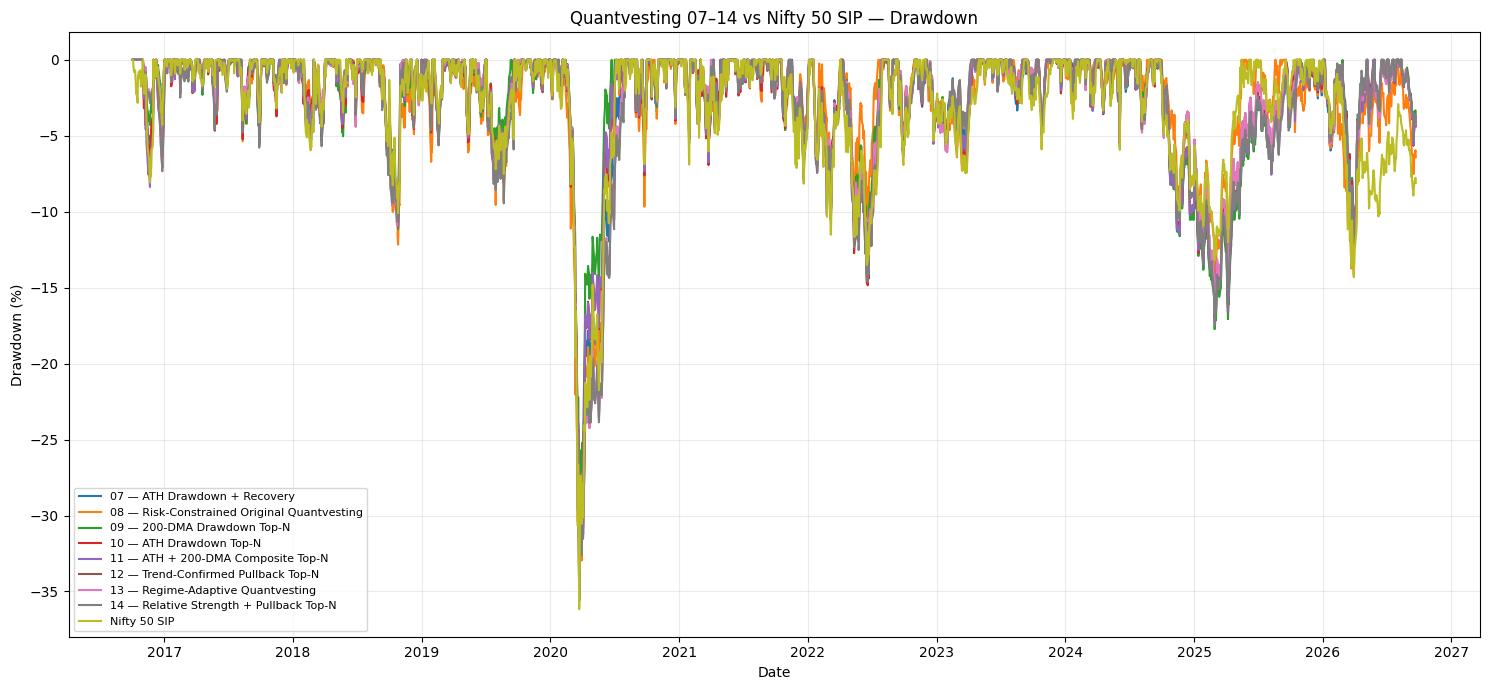

In [18]:
# 18. Drawdown comparison — strategies vs Nifty 50 SIP baseline
plt.figure(figsize=(15,7))
for name,v in results.items(): plt.plot(v["portfolio"].date,v["portfolio"].drawdown*100,label=name)
plt.title("Quantvesting 07–14 vs Nifty 50 SIP — Drawdown")
plt.ylabel("Drawdown (%)");plt.xlabel("Date");plt.grid(alpha=.25);plt.legend(fontsize=8);plt.tight_layout();plt.show()


In [19]:
# 18. Annual / calendar-year comparison
calendar_rows=[]
for name,v in results.items():
    p=v["portfolio"].copy();p["year"]=p.date.dt.year
    for year,g in p.groupby("year"):
        if len(g)<20:continue
        calendar_rows.append({"Strategy":name,"Year":year,"Start Corpus":float(g.portfolio_value.iloc[0]),"End Corpus":float(g.portfolio_value.iloc[-1]),"Year Change":float(g.portfolio_value.iloc[-1]/g.portfolio_value.iloc[0]-1),"Worst DD":float(g.drawdown.min())})
calendar_df=pd.DataFrame(calendar_rows)
display(calendar_df.sort_values(["Year","Strategy"]).style.format({"Start Corpus":"₹{:,.0f}","End Corpus":"₹{:,.0f}","Year Change":"{:.2%}","Worst DD":"{:.2%}"}))

,Strategy,Year,Start Corpus,End Corpus,Year Change,Worst DD
0,07 — ATH Drawdown + Recovery,2016,"₹100,000","₹284,798",184.80%,-6.77%
11,08 — Risk-Constrained Original Quantvesting,2016,"₹100,000","₹283,353",183.35%,-7.47%
22,09 — 200-DMA Drawdown Top-N,2016,"₹100,000","₹291,923",191.92%,-4.29%
33,10 — ATH Drawdown Top-N,2016,"₹100,000","₹283,353",183.35%,-7.47%
44,11 — ATH + 200-DMA Composite Top-N,2016,"₹100,000","₹284,793",184.79%,-8.37%
55,12 — Trend-Confirmed Pullback Top-N,2016,"₹100,000","₹283,610",183.61%,-7.10%
66,13 — Regime-Adaptive Quantvesting,2016,"₹100,000","₹283,610",183.61%,-7.10%
77,14 — Relative Strength + Pullback Top-N,2016,"₹100,000","₹283,423",183.42%,-7.34%
88,Nifty 50 SIP,2016,"₹100,830","₹288,350",185.98%,-8.08%
1,07 — ATH Drawdown + Recovery,2017,"₹387,108","₹1,806,292",366.61%,-5.02%


In [20]:
# 19. Regime attribution using the same descriptive Nifty regime classification for every strategy
bench_raw=yf_download(["^NSEI"],period=HISTORY_PERIOD)
def extract_field(raw,field):
    if raw is None or raw.empty:return pd.Series(dtype=float)
    if isinstance(raw.columns,pd.MultiIndex):
        if field not in raw.columns.get_level_values(0):return pd.Series(dtype=float)
        s=raw[field];s=s.iloc[:,0] if isinstance(s,pd.DataFrame) else s
    else:s=raw[field]
    s=pd.to_numeric(s,errors="coerce").dropna();s.index=pd.to_datetime(s.index).tz_localize(None);return s
nclose=extract_field(bench_raw,"Close")
nb=pd.DataFrame({"close":nclose});nb["dma200"]=nb.close.rolling(200,min_periods=200).mean();nb["peak"]=nb.close.cummax();nb["dd"]=nb.close/nb.peak-1;nb["ret6m"]=nb.close.pct_change(126)
def nreg(r):
    if pd.isna(r.ret6m) or pd.isna(r.dma200):return "Insufficient history"
    if r.dd<=-.10 and r.ret6m<0:return "Stress / Bear"
    if r.dd<=-.10:return "Recovery"
    if r.dd>-.03 and r.ret6m>0 and r.close>=r.dma200:return "Expansion / Bull"
    return "Transition / Sideways"
nb["regime"]=nb.apply(nreg,axis=1)
regime_rows=[]
for name,v in results.items():
    q=v["portfolio"].copy();q["regime"]=q.date.map(nb.regime)
    for rg,g in q.groupby("regime"):
        if len(g)<20:continue
        regime_rows.append({"Strategy":name,"Regime":rg,"Observations":len(g),"Mean Daily Corpus Change":float(g.portfolio_value.pct_change().mean()),"Worst Drawdown Within Regime":float(g.drawdown.min()),"End Corpus":float(g.portfolio_value.iloc[-1])})
regime_df=pd.DataFrame(regime_rows)
display(regime_df.sort_values(["Regime","Strategy"]).style.format({"Mean Daily Corpus Change":"{:.3%}","Worst Drawdown Within Regime":"{:.2%}","End Corpus":"₹{:,.0f}"}))

,Strategy,Regime,Observations,Mean Daily Corpus Change,Worst Drawdown Within Regime,End Corpus
0,07 — ATH Drawdown + Recovery,Expansion / Bull,1065,0.783%,-4.26%,"₹28,436,664"
4,08 — Risk-Constrained Original Quantvesting,Expansion / Bull,1065,0.784%,-4.63%,"₹27,926,678"
8,09 — 200-DMA Drawdown Top-N,Expansion / Bull,1065,0.784%,-4.05%,"₹28,259,576"
12,10 — ATH Drawdown Top-N,Expansion / Bull,1065,0.789%,-4.67%,"₹29,720,518"
16,11 — ATH + 200-DMA Composite Top-N,Expansion / Bull,1065,0.781%,-3.96%,"₹29,042,148"
20,12 — Trend-Confirmed Pullback Top-N,Expansion / Bull,1065,0.786%,-3.71%,"₹27,469,643"
24,13 — Regime-Adaptive Quantvesting,Expansion / Bull,1065,0.786%,-3.71%,"₹27,469,643"
28,14 — Relative Strength + Pullback Top-N,Expansion / Bull,1065,0.790%,-4.59%,"₹28,492,580"
32,Nifty 50 SIP,Expansion / Bull,1065,0.746%,-2.91%,"₹20,289,940"
1,07 — ATH Drawdown + Recovery,Recovery,27,63.268%,-11.48%,"₹29,817,426"


In [21]:
# 20. Capital-utilization and turnover diagnostics
util=metrics[["Average Invested %","Average Cash %","Buy Events","Trim Events","Exit Events","Final Holdings"]].copy()
display(util.style.format({"Average Invested %":"{:.1%}","Average Cash %":"{:.1%}","Buy Events":"{:,.0f}","Trim Events":"{:,.0f}","Exit Events":"{:,.0f}","Final Holdings":"{:,.0f}"}))

,Average Invested %,Average Cash %,Buy Events,Trim Events,Exit Events,Final Holdings
Strategy,,,,,,
07 — ATH Drawdown + Recovery,92.5%,7.5%,"2,142",0,0,40
08 — Risk-Constrained Original Quantvesting,88.2%,11.8%,"6,554",0,117,27
09 — 200-DMA Drawdown Top-N,93.6%,6.4%,"4,258",0,0,40
10 — ATH Drawdown Top-N,94.2%,5.8%,"5,452",0,0,40
11 — ATH + 200-DMA Composite Top-N,94.2%,5.8%,"6,377",0,0,40
12 — Trend-Confirmed Pullback Top-N,90.3%,9.7%,"1,410",0,0,40
13 — Regime-Adaptive Quantvesting,90.3%,9.7%,"1,410",0,0,40
14 — Relative Strength + Pullback Top-N,92.9%,7.1%,"2,529",0,0,40
Nifty 50 SIP,100.0%,0.0%,117,0,0,1


In [22]:
# 21. Trade-ledger concentration diagnostics — descriptive, not a score
rows=[]
for name,v in results.items():
    t=v["trades"]
    if t.empty or "symbol" not in t.columns:continue
    buys=t[t.event.astype(str).str.contains("BUY|ENTRY",regex=True)].copy()
    if buys.empty:continue
    by=buys.groupby("symbol").notional.sum().sort_values(ascending=False);tot=by.sum()
    rows.append({"Strategy":name,"Top-1 cumulative purchase share":by.head(1).sum()/tot if tot else np.nan,"Top-3":by.head(3).sum()/tot if tot else np.nan,"Top-5":by.head(5).sum()/tot if tot else np.nan,"Top-10":by.head(10).sum()/tot if tot else np.nan,"Distinct purchased stocks":by.size})
conc=pd.DataFrame(rows).set_index("Strategy")
display(conc.style.format({c:"{:.1%}" for c in conc.columns if c.startswith("Top-")}))

,Top-1 cumulative purchase share,Top-3,Top-5,Top-10,Distinct purchased stocks
Strategy,,,,,
07 — ATH Drawdown + Recovery,8.3%,22.8%,33.7%,54.9%,40
08 — Risk-Constrained Original Quantvesting,5.0%,13.2%,20.8%,38.0%,52
09 — 200-DMA Drawdown Top-N,5.6%,15.7%,24.7%,42.1%,40
10 — ATH Drawdown Top-N,6.8%,20.2%,31.2%,50.8%,40
11 — ATH + 200-DMA Composite Top-N,6.2%,16.4%,25.7%,44.4%,40
12 — Trend-Confirmed Pullback Top-N,6.3%,15.6%,24.3%,42.7%,40
13 — Regime-Adaptive Quantvesting,6.3%,15.6%,24.3%,42.7%,40
14 — Relative Strength + Pullback Top-N,5.5%,14.4%,22.5%,40.3%,40
Nifty 50 SIP,100.0%,100.0%,100.0%,100.0%,1


In [23]:
# 22. Strategy-specific opportunity histories — every monthly screen used by the backtest
opportunity_history={}
for name in STRATEGIES:
    rows=[]
    for date in sip_dates:
        prev=market_days[market_days<date]
        if len(prev)==0:continue
        sd=pd.Timestamp(prev[-1]);opp=candidates_on_date(sd,name)
        if opp.empty:continue
        for rank,r in opp.reset_index(drop=True).iterrows():
            rec={"strategy":name,"signal_date":sd,"rank":rank+1,"symbol":r.symbol,"conviction":r.conviction,"category":r.category,"Close":r.Close,"ath_gap":r.ath_gap,"dma_gap":r.dma_gap,"pullback":r.pullback,"rs_6m":r.rs_6m,"rs_12m":r.rs_12m,"composite_score":r.get("composite_score",np.nan),"market_regime":r.get("market_regime",np.nan)}
            rows.append(rec)
    opportunity_history[name]=pd.DataFrame(rows)
print({k:len(v) for k,v in opportunity_history.items()})

{'07 — ATH Drawdown + Recovery': 845, '08 — Risk-Constrained Original Quantvesting': 2008, '09 — 200-DMA Drawdown Top-N': 1580, '10 — ATH Drawdown Top-N': 2008, '11 — ATH + 200-DMA Composite Top-N': 2380, '12 — Trend-Confirmed Pullback Top-N': 546, '13 — Regime-Adaptive Quantvesting': 546, '14 — Relative Strength + Pullback Top-N': 903}


In [24]:
# 25. Common implementation audit

audit_rows=[]
for name,v in results.items():
    p=v["portfolio"];t=v["trades"]
    if name==NIFTY_BENCHMARK_NAME:
        audit_rows.append({"Strategy":name,"Integer buys":"N/A — fractional index units","Integer sells":"N/A","Purchase cap":"N/A — index benchmark","Sector cap":"N/A — index benchmark","No negative cash":bool((p.cash>=-1e-8).all()),"Holding limit":"N/A — index benchmark"})
        continue
    buys=t[t.event.astype(str).str.contains("BUY|ENTRY",regex=True)] if not t.empty else pd.DataFrame()
    sales=t[t.event.astype(str).str.contains("TRIM|EXIT",regex=True)] if not t.empty else pd.DataFrame()
    integer_buy=bool(np.all(np.isclose(buys.shares,np.round(buys.shares)))) if not buys.empty else True
    integer_sell=bool(np.all(np.isclose(sales.shares,np.round(sales.shares)))) if not sales.empty else True
    position_ok=bool((buys.position_pct_after<=MAX_POSITION_PCT+1e-9).all()) if not buys.empty and "position_pct_after" in buys else True
    sector_ok=bool((buys.sector_pct_after<=MAX_SECTOR_PCT+1e-9).all()) if not buys.empty and "sector_pct_after" in buys else True
    cash_ok=bool((p.cash>=-1e-8).all())
    holdings_ok=bool((p.open_positions<=MAX_HOLDINGS).all())
    audit_rows.append({"Strategy":name,"Integer buys":integer_buy,"Integer sells":integer_sell,"Purchase cap":position_ok,"Sector cap":sector_ok,"No negative cash":cash_ok,"Holding limit":holdings_ok})
audit_df=pd.DataFrame(audit_rows).set_index("Strategy")
display(audit_df)


,Integer buys,Integer sells,Purchase cap,Sector cap,No negative cash,Holding limit
Strategy,,,,,,
07 — ATH Drawdown + Recovery,True,True,True,True,True,True
08 — Risk-Constrained Original Quantvesting,True,True,True,True,True,True
09 — 200-DMA Drawdown Top-N,True,True,True,True,True,True
10 — ATH Drawdown Top-N,True,True,True,True,True,True
11 — ATH + 200-DMA Composite Top-N,True,True,True,True,True,True
12 — Trend-Confirmed Pullback Top-N,True,True,True,True,True,True
13 — Regime-Adaptive Quantvesting,True,True,True,True,True,True
14 — Relative Strength + Pullback Top-N,True,True,True,True,True,True
Nifty 50 SIP,N/A — fractional index units,N/A,N/A — index benchmark,N/A — index benchmark,True,N/A — index benchmark


In [25]:
# 24. Export a directly comparable CSV pack for every strategy
OUTPUT_ROOT=Path("quantvesting_07_to_14_comparison_outputs");OUTPUT_ROOT.mkdir(exist_ok=True)
def slug(s):return re.sub(r"[^A-Za-z0-9]+","_",s).strip("_").lower()
manifest=[]
for name,v in results.items():
    folder=OUTPUT_ROOT/slug(name);folder.mkdir(exist_ok=True)
    p=v["portfolio"].copy();t=v["trades"].copy()
    p.to_csv(folder/"01_daily_portfolio.csv",index=False);p[p.date.isin(sip_dates)].to_csv(folder/"02_monthly_journey.csv",index=False)
    t.to_csv(folder/"03_trade_ledger.csv",index=False)
    if name in opportunity_history:
        opportunity_history[name].to_csv(folder/"04_opportunity_history.csv",index=False)
    v["contributions"].to_csv(folder/"05_contributions.csv",index=False)
    pd.DataFrame([metrics.loc[name].to_dict()|{"Strategy":name}]).to_csv(folder/"06_strategy_summary.csv",index=False)
    manifest.append({"Strategy":name,"Output folder":str(folder)})
manifest_df=pd.DataFrame(manifest);manifest_df.to_csv(OUTPUT_ROOT/"00_manifest.csv",index=False)
display(manifest_df.style.hide(axis="index"))
print(f"✓ Export pack: {OUTPUT_ROOT.resolve()}")

Strategy,Output folder
07 — ATH Drawdown + Recovery,quantvesting_07_to_14_comparison_outputs/07_ath_drawdown_recovery
08 — Risk-Constrained Original Quantvesting,quantvesting_07_to_14_comparison_outputs/08_risk_constrained_original_quantvesting
09 — 200-DMA Drawdown Top-N,quantvesting_07_to_14_comparison_outputs/09_200_dma_drawdown_top_n
10 — ATH Drawdown Top-N,quantvesting_07_to_14_comparison_outputs/10_ath_drawdown_top_n
11 — ATH + 200-DMA Composite Top-N,quantvesting_07_to_14_comparison_outputs/11_ath_200_dma_composite_top_n
12 — Trend-Confirmed Pullback Top-N,quantvesting_07_to_14_comparison_outputs/12_trend_confirmed_pullback_top_n
13 — Regime-Adaptive Quantvesting,quantvesting_07_to_14_comparison_outputs/13_regime_adaptive_quantvesting
14 — Relative Strength + Pullback Top-N,quantvesting_07_to_14_comparison_outputs/14_relative_strength_pullback_top_n
Nifty 50 SIP,quantvesting_07_to_14_comparison_outputs/nifty_50_sip


✓ Export pack: /content/quantvesting_07_to_14_comparison_outputs


In [26]:
# 26. FINAL COMPARISON SUMMARY — sorted descending by XIRR

final_summary=metrics[["Ending Corpus","Profit","XIRR","Max Drawdown","Average Invested %","Average Cash %","Final Cash","Final Holdings","Buy Events","Trim Events","Exit Events","Contributed Capital"]].copy()
final_summary["Profit % of Contributions"]=final_summary.Profit/final_summary["Contributed Capital"]
final_summary=final_summary.sort_values("XIRR",ascending=False)
final_summary.insert(0,"XIRR Rank",range(1,len(final_summary)+1))
print("="*110)
print("QUANTVESTING 07–14 + NIFTY 50 SIP — FINAL APPLES-TO-APPLES COMPARISON")
print("Sorted descending by XIRR")
print("="*110)
display(final_summary.style.format({"XIRR Rank":"{:,.0f}","Ending Corpus":"₹{:,.0f}","Profit":"₹{:,.0f}","XIRR":"{:.2%}","Max Drawdown":"{:.2%}","Average Invested %":"{:.1%}","Average Cash %":"{:.1%}","Final Cash":"₹{:,.0f}","Final Holdings":"{:,.0f}","Buy Events":"{:,.0f}","Trim Events":"{:,.0f}","Exit Events":"{:,.0f}","Contributed Capital":"₹{:,.0f}","Profit % of Contributions":"{:.1%}"}))


QUANTVESTING 07–14 + NIFTY 50 SIP — FINAL APPLES-TO-APPLES COMPARISON
Sorted descending by XIRR


,XIRR Rank,Ending Corpus,Profit,XIRR,Max Drawdown,Average Invested %,Average Cash %,Final Cash,Final Holdings,Buy Events,Trim Events,Exit Events,Contributed Capital,Profit % of Contributions
Strategy,,,,,,,,,,,,,,
10 — ATH Drawdown Top-N,1,"₹30,854,246","₹18,854,246",18.05%,-33.56%,94.2%,5.8%,"₹1,603,684",40,"5,452",0,0,"₹12,000,000",157.1%
11 — ATH + 200-DMA Composite Top-N,2,"₹30,008,499","₹18,008,499",17.53%,-32.93%,94.2%,5.8%,"₹1,559,659",40,"6,377",0,0,"₹12,000,000",150.1%
07 — ATH Drawdown + Recovery,3,"₹29,890,556","₹17,890,556",17.46%,-33.79%,92.5%,7.5%,"₹1,552,658",40,"2,142",0,0,"₹12,000,000",149.1%
14 — Relative Strength + Pullback Top-N,4,"₹29,689,958","₹17,689,958",17.33%,-35.64%,92.9%,7.1%,"₹1,540,258",40,"2,529",0,0,"₹12,000,000",147.4%
09 — 200-DMA Drawdown Top-N,5,"₹29,506,309","₹17,506,309",17.22%,-30.98%,93.6%,6.4%,"₹1,530,181",40,"4,258",0,0,"₹12,000,000",145.9%
13 — Regime-Adaptive Quantvesting,6,"₹28,288,980","₹16,288,980",16.43%,-35.42%,90.3%,9.7%,"₹1,463,115",40,"1,410",0,0,"₹12,000,000",135.7%
12 — Trend-Confirmed Pullback Top-N,7,"₹28,288,980","₹16,288,980",16.43%,-35.42%,90.3%,9.7%,"₹1,463,115",40,"1,410",0,0,"₹12,000,000",135.7%
08 — Risk-Constrained Original Quantvesting,8,"₹28,122,445","₹16,122,445",16.32%,-35.58%,88.2%,11.8%,"₹1,468,318",27,"6,554",0,117,"₹12,000,000",134.4%
Nifty 50 SIP,9,"₹18,993,300","₹7,293,300",9.45%,-36.17%,100.0%,0.0%,₹0,1,117,0,0,"₹11,700,000",62.3%


## Interpretation discipline

This notebook compares the finalized Quantvesting strategies **07–14** against a passive **Nifty 50 SIP price-index baseline** using the same ₹100,000 monthly contribution schedule and journey dates. The final comparison table is explicitly sorted **descending by XIRR**.

Important benchmark convention: the Nifty 50 baseline uses the **Nifty 50 Price Index (`^NSEI`)** with fractional index units and therefore does not impose the stock-level 5% purchase cap, 20% sector cap, 40-stock limit, or integer-share constraint. It is a passive index baseline rather than an ETF execution simulation. NSE Indices distinguishes the Nifty 50 Price Index from the Nifty 50 Total Returns (TR) index; the price index excludes dividends, while the TR index incorporates dividends. For a fully investable passive benchmark, a future version can add Nifty 50 TRI / ETF tracking separately.

Do not optimize parameters from the resulting performance. Use the outputs to compare ending corpus, XIRR, drawdown path, capital utilization, turnover, concentration, calendar periods and market regimes. The benchmark is included to answer the central research question: **does a Quantvesting strategy add value over a simple Nifty 50 SIP under the same contribution journey?**

The **08 Original Quantvesting** strategy remains structurally different because it has a daily frozen-ATH exit mechanism; its turnover and cash redeployment should therefore be interpreted separately from the no-routine-sell strategies.
